In [1]:
import os
import cv2
import numpy as np

In [14]:
def degradar_imagen(imagen, escala=4, agregar_ruido=True, sigma_ruido=5):
    h, w = imagen.shape

    # Blur ligeramente más suave para sujetos con alto contraste
    blur = cv2.GaussianBlur(imagen, (3, 3), sigmaX=0.8)  # era 0.5

    lr_small = cv2.resize(blur, (w // escala, h // escala),
                          interpolation=cv2.INTER_LINEAR)

    # Bicúbico en lugar de Lanczos para el upscale
    # Lanczos genera ringing en bordes de alto contraste (gafas, barba)
    lr_upscaled = cv2.resize(lr_small, (w, h),
                             interpolation=cv2.INTER_CUBIC)  # era LANCZOS4

    if agregar_ruido:
        ruido = np.random.normal(0, sigma_ruido,
                                 lr_upscaled.shape).astype(np.float32)
        lr_upscaled = np.clip(
            lr_upscaled.astype(np.float32) + ruido, 0, 255
        ).astype(np.uint8)

    return lr_upscaled

In [15]:
def procesar_dataset(ruta_entrada, ruta_salida,
                     escala=4, sigma_ruido=5, agregar_ruido=True):
    """
    Recorre dataset/Training y guarda imágenes degradadas en ruta_salida.
    Mantiene la estructura de carpetas por sujeto (s1, s2, ...).
    Conserva dimensiones originales 112×92.
    """
    os.makedirs(ruta_salida, exist_ok=True)
    conteo      = 0
    conteo_err  = 0

    sujetos = sorted(os.listdir(ruta_entrada))
    print(f"Sujetos encontrados: {len(sujetos)}")
    print(f"Escala     : ×{escala}")
    print(f"Ruido      : sigma={sigma_ruido if agregar_ruido else 0}")
    print(f"Blur       : GaussianBlur (3×3, sigma=0.5)")
    print(f"Upscale    : INTER_LANCZOS4")
    print(f"Dimensiones: conservadas (112×92)")
    print("─" * 45)

    for sujeto in sujetos:
        carpeta_entrada = os.path.join(ruta_entrada, sujeto)
        if not os.path.isdir(carpeta_entrada):
            continue

        carpeta_salida = os.path.join(ruta_salida, sujeto)
        os.makedirs(carpeta_salida, exist_ok=True)

        for archivo in sorted(os.listdir(carpeta_entrada)):
            ext = os.path.splitext(archivo)[1].lower()
            if ext not in {'.pgm', '.png', '.jpg', '.jpeg', '.bmp'}:
                continue

            ruta_img = os.path.join(carpeta_entrada, archivo)
            img_hr   = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)

            if img_hr is None:
                print(f"  ⚠ No se pudo leer: {ruta_img}")
                conteo_err += 1
                continue

            # Verificar dimensiones
            if img_hr.shape != (112, 92):
                img_hr = cv2.resize(img_hr, (92, 112),
                                    interpolation=cv2.INTER_LANCZOS4)

            img_lr = degradar_imagen(img_hr, escala, agregar_ruido, sigma_ruido)

            # Guardar como .png
            nombre    = os.path.splitext(archivo)[0] + ".png"
            ruta_dest = os.path.join(carpeta_salida, nombre)
            cv2.imwrite(ruta_dest, img_lr)
            conteo += 1

    print(f"✓ {conteo} imágenes guardadas → {ruta_salida}")
    if conteo_err:
        print(f"⚠ {conteo_err} imágenes no procesadas")

In [16]:
def verificar_muestra(ruta_entrada, escala=4, sigma_ruido=5, n=5):
    """
    Muestra HR vs LR degradada para un sujeto antes de procesar el dataset.
    Llama a esto primero para confirmar que el resultado visual es el esperado.
    """
    import matplotlib.pyplot as plt

    ruta_s1  = os.path.join(ruta_entrada, "s14")
    archivos = sorted(os.listdir(ruta_s1))[:n]

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for i, archivo in enumerate(archivos):
        ruta = os.path.join(ruta_s1, archivo)
        hr   = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        lr   = degradar_imagen(hr, escala=escala, sigma_ruido=sigma_ruido)

        axes[0, i].imshow(hr, cmap='gray')
        axes[0, i].set_title(f"HR\n{archivo}", fontsize=8)
        axes[0, i].axis('off')

        axes[1, i].imshow(lr, cmap='gray')
        axes[1, i].set_title(f"LR ×{escala}\n112×92", fontsize=8)
        axes[1, i].axis('off')

    plt.suptitle(f"Verificación degradación ×{escala} — s1", fontweight='bold')
    plt.tight_layout()
    plt.show()

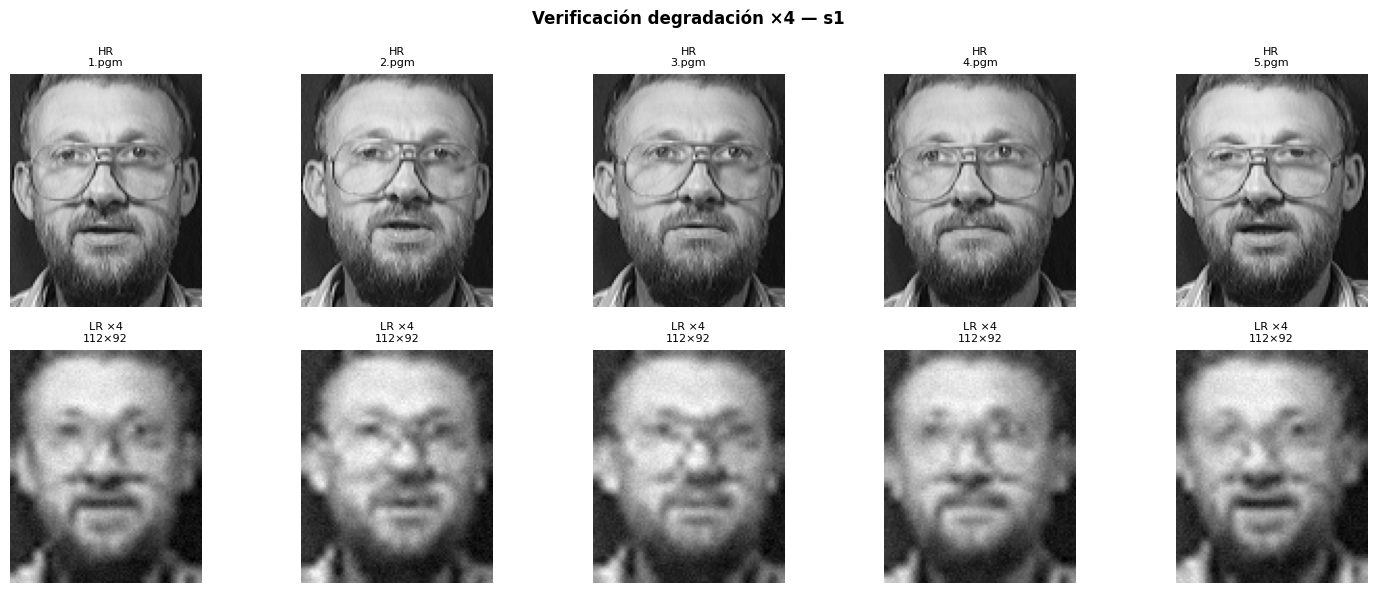

In [17]:
verificar_muestra(
    ruta_entrada = "dataset/Training",
    escala       = 4,
    sigma_ruido  = 5
)


In [18]:
procesar_dataset(
    ruta_entrada  = "dataset/Training",
    ruta_salida   = "dataset/Training_LR_escala4",
    escala        = 4,
    sigma_ruido   = 5,
    agregar_ruido = True
)

Sujetos encontrados: 40
Escala     : ×4
Ruido      : sigma=5
Blur       : GaussianBlur (3×3, sigma=0.5)
Upscale    : INTER_LANCZOS4
Dimensiones: conservadas (112×92)
─────────────────────────────────────────────
✓ 360 imágenes guardadas → dataset/Training_LR_escala4
